In [112]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
from pandas.plotting import scatter_matrix
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf

In [113]:
# Load Train and Test datasets.
TRAIN_LOAD_LOCATION = '../data/raw/train.xlsx'
TEST_LOAD_LOCATION = '../data/raw/test.xlsx'

df = pd.read_excel(TRAIN_LOAD_LOCATION)
df_test = pd.read_excel(TEST_LOAD_LOCATION)

In [115]:
df.info()
df.head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17544 entries, 0 to 17543
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Year         17544 non-null  int64  
 1   Month        17544 non-null  int64  
 2   Day          17544 non-null  int64  
 3   Hour         17544 non-null  int64  
 4   Load         17544 non-null  int64  
 5   Site-1 Temp  17544 non-null  float64
 6   Site-2 Temp  17544 non-null  float64
 7   Site-3 Temp  17544 non-null  float64
 8   Site-4 Temp  17544 non-null  float64
 9   Site-5 Temp  17544 non-null  float64
 10  Site-1 GHI   17544 non-null  int64  
 11  Site-2 GHI   17544 non-null  int64  
 12  Site-3 GHI   17544 non-null  int64  
 13  Site-4 GHI   17544 non-null  int64  
 14  Site-5 GHI   17544 non-null  int64  
dtypes: float64(5), int64(10)
memory usage: 2.0 MB


,Year,Month,Day,Hour,Load,Site-1 Temp,Site-2 Temp,Site-3 Temp,Site-4 Temp,Site-5 Temp,Site-1 GHI,Site-2 GHI,Site-3 GHI,Site-4 GHI,Site-5 GHI
0,1,1,1,1,1997,8.0,8.2,5.3,9.4,8.1,0,0,0,0,0
1,1,1,1,2,1921,8.3,8.6,5.2,8.6,7.1,0,0,0,0,0
2,1,1,1,3,1861,8.1,8.8,5.1,8.7,6.2,0,0,0,0,0
3,1,1,1,4,1833,7.6,8.1,4.3,8.5,6.0,0,0,0,0,0
4,1,1,1,5,1847,7.3,7.5,4.0,8.6,6.9,0,0,0,0,0
5,1,1,1,6,1910,6.6,7.3,4.0,7.8,7.3,0,0,0,0,0
6,1,1,1,7,1972,6.9,7.6,5.3,7.7,7.1,0,0,0,0,0
7,1,1,1,8,1919,6.8,7.1,5.8,7.3,7.3,0,0,0,0,0
8,1,1,1,9,1786,9.3,9.1,8.2,9.3,9.4,73,70,65,77,79
9,1,1,1,10,1689,13.0,13.9,13.7,13.1,12.7,245,238,245,251,252


In [116]:
df.describe()

,Year,Month,Day,Hour,Load,Site-1 Temp,Site-2 Temp,Site-3 Temp,Site-4 Temp,Site-5 Temp,Site-1 GHI,Site-2 GHI,Site-3 GHI,Site-4 GHI,Site-5 GHI
count,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000
mean,1.499316,6.519836,15.738714,12.500000,2154.130529,17.014774,16.820007,18.034553,17.394009,17.220611,223.523142,220.641473,226.133037,225.189352,226.739398
std,0.500014,3.449649,8.804172,6.922384,437.248479,4.685375,4.361498,7.193631,4.569890,5.619762,303.444470,300.121626,306.856188,305.596998,307.053012
min,1.000000,1.000000,1.000000,1.000000,1027.000000,1.900000,2.900000,-0.500000,2.600000,0.900000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,4.000000,8.000000,6.750000,1847.000000,13.700000,13.700000,12.500000,14.100000,13.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,7.000000,16.000000,12.500000,2085.000000,17.100000,17.000000,17.300000,17.400000,17.000000,12.000000,12.000000,12.000000,11.000000,12.000000
75%,2.000000,10.000000,23.000000,18.250000,2392.000000,20.200000,19.900000,22.700000,20.400000,20.800000,431.000000,424.000000,434.000000,432.250000,434.000000
max,2.000000,12.000000,31.000000,24.000000,4397.000000,36.600000,31.900000,43.000000,36.600000,39.700000,1037.000000,1028.000000,1041.000000,1047.000000,1049.000000


## Data Overview

The dataset contains hourly electricity load for the San Diego region along with exogenous weather variables, including temperature and global horizontal irradiance measurements at five sites in the region, and the date and hour.


In [2]:
def eda_df_transformer(df):

    YEARS_DICT = {1:2020, 2:2021, 3:2022}

    TEMP_COLS = [f"Site-{i + 1} Temp" for i in range(5)]
    GHI_COLS = [f"Site-{i + 1} GHI" for i in range(5)]

    df_transformed = df.copy()
    
    # Transform temperature readings to Farenheit.
    df_transformed[TEMP_COLS] = df_transformed[TEMP_COLS].apply(lambda x: x * 9/5 + 32)
    
    # Average the temperature and GHI measurements across all sites, to explore temperature effects simply.
    df_transformed["avg_region_temp"] = df_transformed[TEMP_COLS].mean(axis=1)
    df_transformed["avg_region_ghi"] = df_transformed[GHI_COLS].mean(axis=1)

    # Create timestamps.
    df_transformed['Year'] = df_transformed['Year'].map(YEARS_DICT)
    df_transformed['Hour'] = df_transformed['Hour'] - 1
    df_transformed['timestamp'] = pd.to_datetime(df_transformed[['Year', 'Month', 'Day', 'Hour']])

    # Ensure chronological ordering.
    df_transformed = df_transformed.sort_values("timestamp")

    # Add feature indicating weekend.
    df_transformed['is_weekend'] = (df_transformed['timestamp'].dt.weekday >= 5).astype(int)

    # Rearrange columns

    cols = list(df_transformed.columns)
    cols.remove("timestamp")
    df_transformed = df_transformed[["timestamp"] + cols]

    return df_transformed

In [119]:
df = eda_transform(df)
df_test = eda_transform(df_test)

In [125]:
# Save transformed Train and Test datasets.
TRAIN_SAVE_LOCATION = '../data/processed/train_eda_transformed.csv'
TEST_SAVE_LOCATION = '../data/processed/test_eda_transformed.csv'

df.to_csv(TRAIN_SAVE_LOCATION, index = False)
df_test.to_csv(TEST_SAVE_LOCATION, index = False)

In [634]:
sample_weekend_datetime = "2020-07-14 00:00:00"

df[df['timestamp'] == sample_weekend_datetime]

,Year,Month,Day,Hour,Load,Site-1 Temp,Site-2 Temp,Site-3 Temp,Site-4 Temp,Site-5 Temp,Site-1 GHI,Site-2 GHI,Site-3 GHI,Site-4 GHI,Site-5 GHI,avg_region_temp,avg_region_ghi,timestamp,is_weekend
4680,2020,7,14,0,2137,68.0,69.08,64.76,68.54,66.38,0,0,0,0,0,67.352,0.0,2020-07-14,0


In [659]:
def get_day_load(df, date):
    # Helper function. Gets daily load profile for a specified datetime.
    day_df = df[
        (df["Year"] == date.year) &
        (df["Month"] == date.month) &
        (df["Day"] == date.day)
    ][["timestamp", "Load", "avg_region_temp"]].copy()
    
    day_df["hour"] = day_df["timestamp"].dt.hour
    return day_df

In [648]:
winter_weekend_loads = get_day_load(df, pd.to_datetime("2020-01-12 00:00:00"))
winter_weekday_loads = get_day_load(df, pd.to_datetime("2020-01-14 00:00:00"))
summer_weekend_loads = get_day_load(df, pd.to_datetime("2020-07-12 00:00:00"))
summer_weekday_loads = get_day_load(df, pd.to_datetime("2020-07-14 00:00:00"))
winter_holiday_loads = get_day_load(df, pd.to_datetime("2020-11-26 00:00:00")) # Thanksgiving
summer_holiday_loads = get_day_load(df, pd.to_datetime("2020-07-04 00:00:00")) # Independence Day

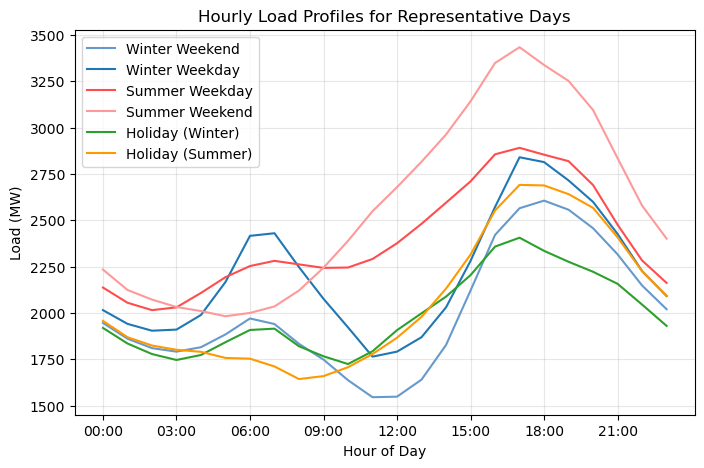

In [654]:
fig, ax = plt.subplots(1, 1, figsize = (8,5))

ax.grid(alpha=0.3)
ax.set_title("Hourly Load Profiles for Representative Days")

ax.plot(winter_weekend_loads["hour"], winter_weekend_loads["Load"], label = "Winter Weekend", color = "#6699cc")
ax.plot(winter_weekday_loads["hour"], winter_weekday_loads["Load"], label = "Winter Weekday", color = "#1f77b4")
ax.plot(summer_weekday_loads["hour"], summer_weekday_loads["Load"], label = "Summer Weekday", color = "#ff4d4d")
ax.plot(summer_weekend_loads["hour"], summer_weekend_loads["Load"], label = "Summer Weekend", color = "#ff9999")
ax.plot(winter_holiday_loads["hour"], winter_holiday_loads["Load"], label = "Holiday (Winter)", color = "#2ca02c")
ax.plot(summer_holiday_loads["hour"], summer_holiday_loads["Load"], label = "Holiday (Summer)", color = "#ff9900")

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Load (MW)")

tick_hours = range(0,24,3)

ax.set_xticks(tick_hours)
ax.set_xticklabels([f"{h:02d}:00" for h in tick_hours])

ax.legend()


The above plot shows representative single-day load profiles to illustrate qualitative differences across seasons and calendar types. Aggregate statistics are examined later.

Observations:

- Load in the summer is generally greater than in the winter. (Consistent with increased air-conditioning demand.)
- In the selected examples, summer weekend load exceeds summer weekday load, while winter weekday load exceeds winter weekend load.
- Load generally has two peaks, one in the morning ~6am, and one in the evening ~6pm. (Most likely the hours when people wake up, and when people get home from work, respectively.)
- Load on holidays is generally less than the average load for a normal day in the same season.



[Text(0, 0, '00:00'),
 Text(3, 0, '03:00'),
 Text(6, 0, '06:00'),
 Text(9, 0, '09:00'),
 Text(12, 0, '12:00'),
 Text(15, 0, '15:00'),
 Text(18, 0, '18:00'),
 Text(21, 0, '21:00')]

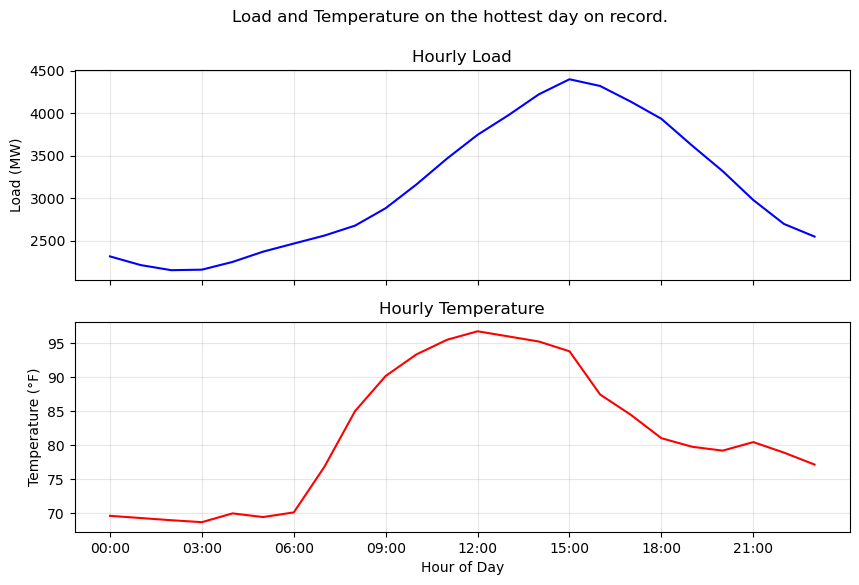

In [679]:
hottest_day = df.loc[df["avg_region_temp"].idxmax(), "timestamp"]
hottest_day_df = get_day_load(df, hottest_day)

fig, axs = plt.subplots(2, 1, figsize = (10, 6), sharex = True)

axs[0].grid(alpha=0.3)
axs[1].grid(alpha=0.3)

axs[0].set_title("Hourly Load")
axs[1].set_title("Hourly Temperature")

axs[0].plot(hottest_day_df["hour"], hottest_day_df["Load"], color='blue')
axs[1].plot(hottest_day_df["hour"], hottest_day_df["avg_region_temp"], color='red')

axs[1].set_xlabel("Hour of Day")
axs[0].set_ylabel("Load (MW)")
axs[1].set_ylabel("Temperature (°F)")
fig.suptitle("Load and Temperature on the hottest day on record.")

tick_hours = range(0,24,3)

axs[1].set_xticks(tick_hours)
axs[1].set_xticklabels([f"{h:02d}:00" for h in tick_hours])

The above plot shows hourly load and temperature on the hottest day on record, September 30, 2020.  
The peak in electricity load does not coincide exactly with the peak temperature; instead, it occurs a few hours later. This lag is typical on hot days and is driven by thermal inertia in buildings and delayed air-conditioning response, causing demand to continue rising even after temperatures peak.

This observation motivates feature engineering beyond the current temperature, such as lagged temperature, rolling averages, or Cooling Degree Hours (CDH), to capture the effects of thermal inertia in load forecasting models.

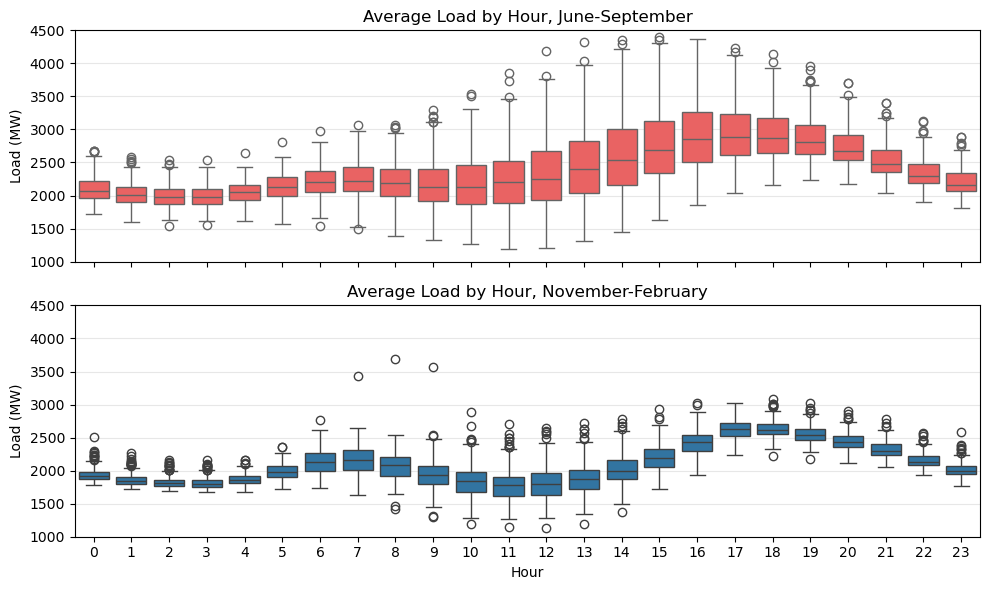

In [697]:
summer_df = df[(df["Month"] >= 6) & (df["Month"] <= 9)][["Load", "Hour", "avg_region_temp"]]
winter_df = df[(df["Month"] >= 11) | (df["Month"] <= 2)][["Load", "Hour", "avg_region_temp"]]

fig, axs = plt.subplots(2, 1, figsize=(10,6), sharex=True)

axs[0].grid(alpha=0.3)
axs[1].grid(alpha=0.3)

sns.boxplot(data=summer_df, x="Hour", y="Load", ax=axs[0], color = "#ff4d4d")
axs[0].set_title("Average Load by Hour, June-September")
axs[0].set_ylabel("Load (MW)")
axs[0].set_ylim(1000, 4500)

sns.boxplot(data=winter_df, x="Hour", y="Load", ax=axs[1], color= "#1f77b4")
axs[1].set_title("Average Load by Hour, November-February")
axs[1].set_xlabel("Hour")
axs[1].set_ylabel("Load (MW)")
axs[1].set_ylim(1000, 4500)

plt.tight_layout()
plt.show()

The above box plots show the distribution of hourly load by hour of day for summer (June–September) and winter (November–February). The wider boxes in summer indicate greater variability in load, likely due to more variable air-conditioning demand and temperature extremes. The narrower boxes in winter suggest more consistent load patterns.

Median load is higher in summer for most hours, and the interquartile range is wider, highlighting both higher average demand and higher variability.

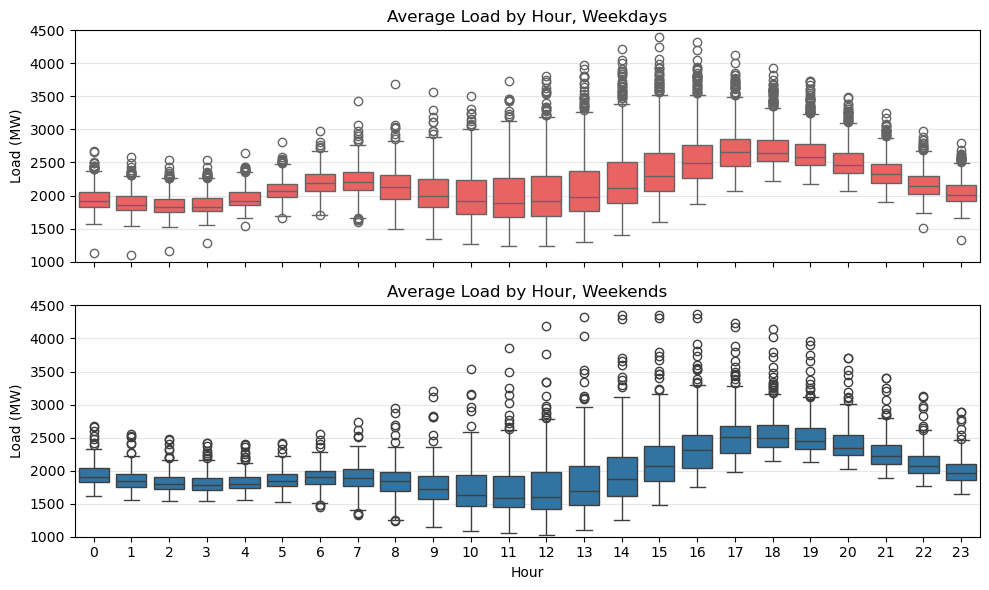

In [707]:
weekday_df = df[df['is_weekend'] == 0][["Load", "Hour", "avg_region_temp"]]
weekend_df = df[df['is_weekend'] == 1][["Load", "Hour", "avg_region_temp"]]

fig, axs = plt.subplots(2, 1, figsize=(10,6), sharex=True)

axs[0].grid(alpha=0.3)
axs[1].grid(alpha=0.3)

sns.boxplot(data = weekday_df, x="Hour", y="Load", ax=axs[0], color = "#ff4d4d")
axs[0].set_title("Average Load by Hour, Weekdays")
axs[0].set_ylabel("Load (MW)")
axs[0].set_ylim(1000, 4500)

sns.boxplot(data = weekend_df, x="Hour", y="Load", ax=axs[1], color= "#1f77b4")
axs[1].set_title("Average Load by Hour, Weekends")
axs[1].set_xlabel("Hour")
axs[1].set_ylabel("Load (MW)")
axs[1].set_ylim(1000, 4500)

plt.tight_layout()
plt.show()

The above box plots show the distribution of hourly load by hour of day for weekdays and weekends. Midday load on weekdays is generally higher than on weekends, reflecting increased commercial and industrial activity. Weekday mornings exhibit a pronounced peak around 6–9 AM, whereas weekends show a smaller or absent morning peak, consistent with later residential wake times and reduced commuting. Evening peaks occur on both weekdays and weekends, though they are slightly higher on weekdays due to the combined residential and commercial electricity use. Overall, the interquartile range is narrower on weekends, indicating more consistent and less variable load patterns compared to weekdays.

[Text(0, 0, '00:00'),
 Text(3, 0, '03:00'),
 Text(6, 0, '06:00'),
 Text(9, 0, '09:00'),
 Text(12, 0, '12:00'),
 Text(15, 0, '15:00'),
 Text(18, 0, '18:00'),
 Text(21, 0, '21:00')]

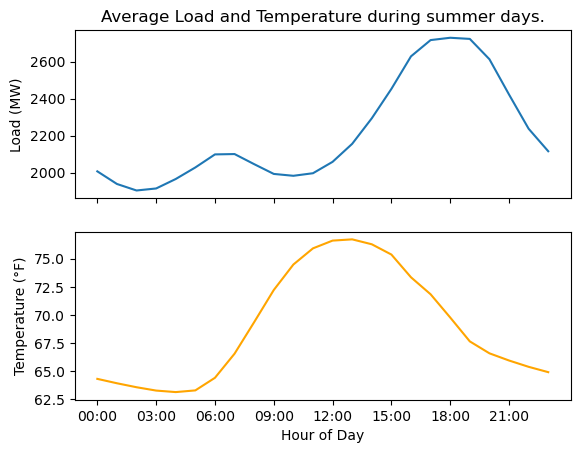

In [557]:
fig, axs = plt.subplots(2, 1, sharex = True)

axs[0].plot(summer_hourly_avgs["Hour"], summer_hourly_avgs["Load"], label = "Average Load")
axs[1].plot(summer_hourly_avgs["Hour"], summer_hourly_avgs["avg_region_temp"], label = "Average Temperature", color = "orange")

axs[1].set_xlabel("Hour of Day")

axs[1].set_xlabel("Hour of Day")
axs[0].set_ylabel("Load (MW)")
axs[1].set_ylabel("Temperature (°F)")

axs[0].set_title("Average Load and Temperature during summer days.")

tick_hours = range(0,24,3)

axs[1].set_xticks(tick_hours)
axs[1].set_xticklabels([f"{h:02d}:00" for h in tick_hours])


The above plots generalize the previously noted observation by averaging load and temperature across all the days in the months June and July in the dataset.

/var/folders/x5/mt3y0q2n65zcpd0hz503pkx00000gn/T/ipykernel_64360/3442187308.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_stats = load_temp_df.groupby("temp_bin")["Load"].agg(["mean", "std"]).reset_index()


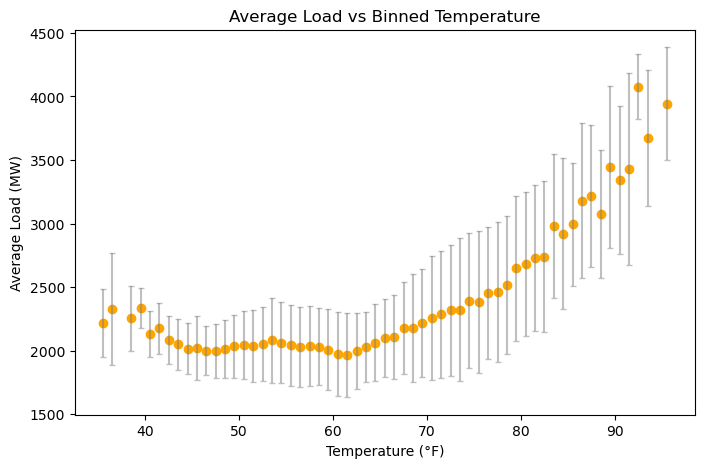

In [585]:
load_temp_df = df[["Load", "avg_region_temp"]].copy()

load_temp_df["temp_bin"] = pd.cut(load_temp_df["avg_region_temp"], bins=range(int(load_temp_df["avg_region_temp"].min()), int(load_temp_df["avg_region_temp"].max())+1, 1))

binned_stats = load_temp_df.groupby("temp_bin")["Load"].agg(["mean", "std"]).reset_index()
binned_stats["temp_mid"] = binned_stats["temp_bin"].apply(lambda x: x.mid)

plt.figure(figsize=(8,5))
plt.scatter(binned_stats["temp_mid"], binned_stats["mean"], color = "orange")

plt.errorbar(
    binned_stats["temp_mid"], 
    binned_stats["mean"], 
    yerr=binned_stats["std"], 
    fmt="none",
    ecolor="gray",
    alpha=0.5,
    capsize=2
)

plt.xlabel("Temperature (°F)")
plt.ylabel("Average Load (MW)")
plt.title("Average Load vs Binned Temperature")
plt.show()


The plot above illustrates the relationship between electric load and temperature across all hours in the dataset. Temperature values are binned into 1°F intervals, and the mean load within each bin is plotted. Error bars represent ±1 standard deviation of the load for each temperature bin. For temperatures above approximately 65°F, load exhibits a roughly linear increase with temperature, consistent with cooling-driven demand. Additionally, load variability increases at higher temperatures, reflecting greater heterogeneity in air-conditioning usage, building characteristics, and behavioral responses during hot conditions.

<Figure size 1000x400 with 0 Axes>

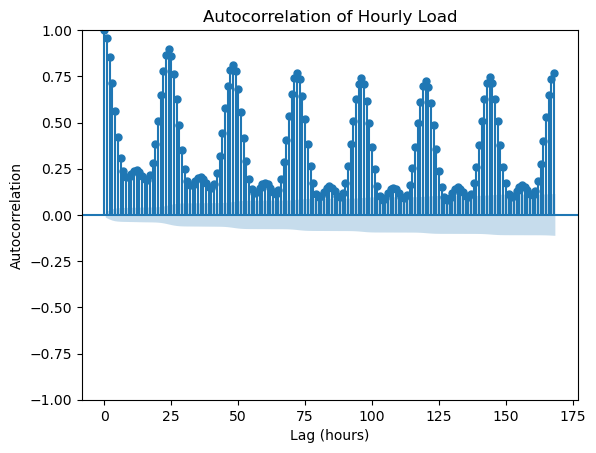

In [602]:
plt.figure(figsize=(10,4))
plot_acf(df["Load"], lags=168)  # 168 = 7 days of hourly lags
plt.xlabel("Lag (hours)")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation of Hourly Load")
plt.show()

The plot above shows the autocorrelation function (ACF) of the hourly electrical load for lags up to 168 hours (one week). Strong autocorrelation is observed at 24-hour multiples, reflecting the dominant daily cycle in electricity demand. Additionally, autocorrelation at short lags (e.g., 1–2 hours) is also high, indicating strong short-term persistence in load. These results highlight the importance of including lagged electrical load as a feature in forecasting models.